# Phase 2 Step 1 — Universe Construction (`01_universe_construction.ipynb`)

> **목적**: 매년 시총 상위 50 종목 universe 산정 (S&P 500 멤버 중).
>
> **결정사항** (PLAN.md §2):
> - 결정 2: 부족 종목은 51위 이하 자동 대체 (max 80 후보 검토)
> - 결정 3: 시총 데이터 출처 = Wikipedia + yfinance (서윤범 01 로직 재사용)

## 산출물

| 파일 | 설명 |
|---|---|
| `data/sp500_membership.pkl` | 시점별 S&P 500 멤버십 캐시 |
| `data/shares_outstanding.pkl` | 종목별 발행주식수 시계열 캐시 |
| `data/prices_close_universe.pkl` | 종목별 일별 종가 캐시 |
| `data/universe_top50_history.csv` | **본 단계 핵심 산출물** (50×6 행) |
| `outputs/01_universe/yearly_changes.png` | 연도별 universe 변동 비율 |
| `outputs/01_universe/mcap_distribution.png` | 시총 분포 (rank vs 시총) |

## 검증 사항

- 6 OOS 연도 (2020~2025) × 50 종목 = 300 entries
- unique 종목 80~120개 예상
- 매년 변경 비율 5~15% 예상 (대형주 안정성)
- look-ahead 차단: cutoff = (year-1)년 12월 31일 (또는 직전 영업일)

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 부트스트랩 + 모듈 import |
| §2 | universe history 빌드 (캐싱 포함, 첫 실행 ~10분) |
| §3 | 결과 검증 (행 수, unique 종목, 변경 비율) |
| §4 | 시각화 (변동 비율 + 시총 분포) |
| §5 | CSV 저장 |


## §1. 환경 부트스트랩

scripts/setup.py 의 `bootstrap()` 으로 한글 폰트, 시드, 디렉토리 한 번에 처리.

In [1]:
# Jupyter 모듈 자동 리로드 — scripts/universe.py 등 변경 시 자동 반영
# (이 두 줄 없으면 모듈 코드를 수정해도 Jupyter 가 이전 버전을 계속 사용함)
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.setup import bootstrap, BASE_DIR, DATA_DIR, OUTPUTS_DIR
from scripts.universe import build_universe_history

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '01_universe'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'\nDATA_DIR : {DATA_DIR}')
print(f'OUT_DIR  : {OUT_DIR}')

c:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\scripts\universe.py:439: SyntaxWarning: invalid escape sequence '\$'
  """이중상장 종목 통합: secondary 제거, primary 시총 유지.


  Phase 2 BL Integration — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility

DATA_DIR : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\data
OUT_DIR  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\outputs\01_universe


## §2. Universe History 빌드

- 6 OOS 연도 (2020 ~ 2025)
- 매년 시총 상위 50 종목
- max 80 후보 검토 (가용성 검증 통과 시 50 채움)
- 가용성 임계: ≥ 1,732 영업일 (≈ 7.7년, IS 5년 + 워밍업 + 마진)

⚠️ **첫 실행**: Wikipedia 조회 + yfinance 다운로드로 약 5~15분 소요.
**재실행**: 캐시 활용으로 <30초.

In [2]:
OOS_YEARS = list(range(2020, 2026))   # 2020 ~ 2025
N_TOP = 50
MAX_CANDIDATES = 80
MIN_DATA_DAYS = 1732   # 약 7.7년

history = build_universe_history(
    years=OOS_YEARS,
    cache_dir=DATA_DIR,
    n_top=N_TOP,
    max_candidates=MAX_CANDIDATES,
    min_data_days=MIN_DATA_DAYS,
)

print(f'\nuniverse history shape: {history.shape}')
print(f'expected: ({len(OOS_YEARS) * N_TOP}, ?)\n')
history.head(10)

  [universe] 전체 unique 멤버: 755 종목
  [universe] 종가 데이터: (3270, 755) (행=3270, 종목=755)
  [universe] 발행주식수 수집: 15개 신규 종목
  [universe] 발행주식수 저장 완료 (740 종목) → shares_outstanding.pkl
  [universe] 발행주식수 데이터: 740 종목
  [universe] 분할 이력 데이터: 755 종목
  [universe] 2020: 50 종목 산정 완료 (cutoff=2019-12-31)
  [universe] 2021: 50 종목 산정 완료 (cutoff=2020-12-31)
  [universe] 2022: 50 종목 산정 완료 (cutoff=2021-12-31)
  [universe] 2023: 50 종목 산정 완료 (cutoff=2022-12-31)
  [universe] 2024: 50 종목 산정 완료 (cutoff=2023-12-31)
  [universe] 2025: 50 종목 산정 완료 (cutoff=2024-12-31)

universe history shape: (300, 6)
expected: (300, ?)



,oos_year,ticker,mcap_rank,mcap_value,cutoff_date,is_new
0,2020,AAPL,1,1258075438334.062500,2019-12-31,True
1,2020,MSFT,2,1139685185245.468750,2019-12-31,True
2,2020,AMZN,3,916153496751.093750,2019-12-31,True
3,2020,GOOGL,4,914972013945.937500,2019-12-31,True
4,2020,BRK-B,5,553880853120.000000,2019-12-31,True
5,2020,V,6,399423171013.171875,2019-12-31,True
6,2020,JPM,7,367005011342.773438,2019-12-31,True
7,2020,JNJ,8,322546734494.824219,2019-12-31,True
8,2020,WMT,9,309212596969.986328,2019-12-31,True
9,2020,MA,10,290319640324.972656,2019-12-31,True


## §3. 결과 검증

- 행 수: 6 × 50 = 300 (정확히)
- unique 종목: 80~120 예상
- 매년 50 종목 정확히 산출 (fallback 으로 100% 채움)
- 매년 변경 비율 (전년 대비 신규 편입) 합리성 (5~15% 예상)

In [3]:
# 검증 1: 행 수
n_expected = len(OOS_YEARS) * N_TOP
n_actual = len(history)
print(f'행 수 검증: {n_actual} / {n_expected} {"✅" if n_actual == n_expected else "⚠️"}')

# 검증 2: 매년 50 종목 정확히
counts = history.groupby('oos_year').size()
print(f'\n연도별 종목 수:')
for year, n in counts.items():
    print(f'  {year}: {n} 종목 {"✅" if n == N_TOP else "⚠️"}')

# 검증 3: unique 종목
unique_tickers = history['ticker'].unique()
print(f'\nunique 종목 수: {len(unique_tickers)}')

# 검증 4: 매년 변경 비율
print(f'\n연도별 변동 (신규 편입 종목 수):')
for year in OOS_YEARS:
    n_new = history.loc[(history['oos_year'] == year) & history['is_new']].shape[0]
    pct = n_new / N_TOP * 100
    print(f'  {year}: 신규 {n_new}/{N_TOP} ({pct:.0f}%)')

행 수 검증: 300 / 300 ✅

연도별 종목 수:
  2020: 50 종목 ✅
  2021: 50 종목 ✅
  2022: 50 종목 ✅
  2023: 50 종목 ✅
  2024: 50 종목 ✅
  2025: 50 종목 ✅

unique 종목 수: 74

연도별 변동 (신규 편입 종목 수):
  2020: 신규 50/50 (100%)
  2021: 신규 6/50 (12%)
  2022: 신규 5/50 (10%)
  2023: 신규 8/50 (16%)
  2024: 신규 9/50 (18%)
  2025: 신규 7/50 (14%)


## §4. 시각화

1. 연도별 신규 편입 종목 수 — 대형주 안정성 (5~15%)
2. 시총 분포 (rank vs mcap) — power law 확인

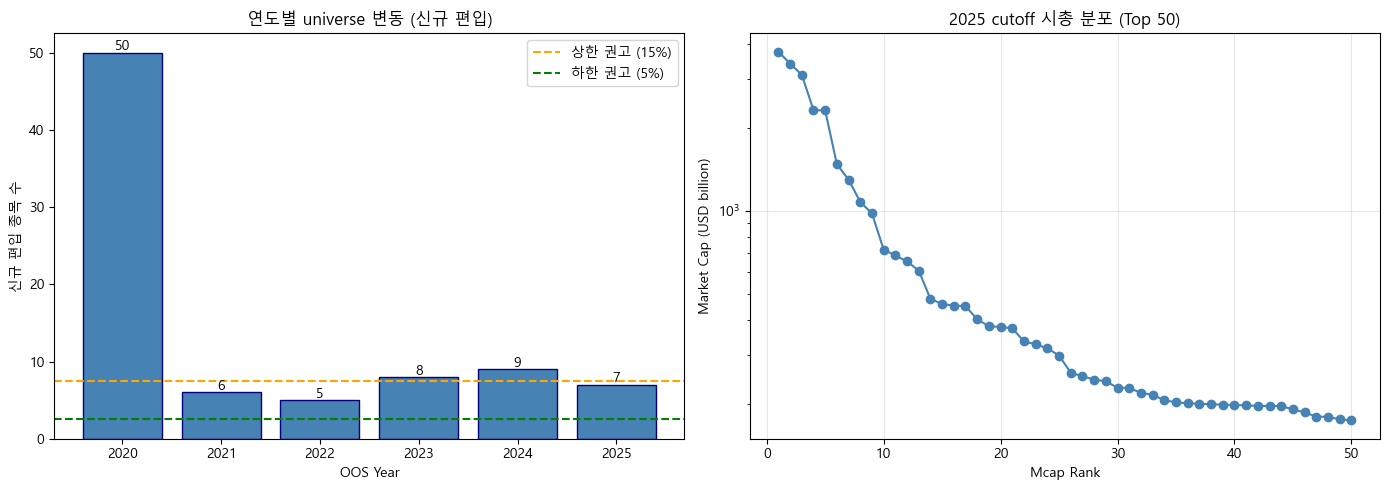

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4-1. 연도별 신규 편입 비율
yearly_new = history[history['is_new']].groupby('oos_year').size()
yearly_new = yearly_new.reindex(OOS_YEARS, fill_value=0)
ax = axes[0]
bars = ax.bar(yearly_new.index, yearly_new.values, color='steelblue', edgecolor='navy')
ax.axhline(N_TOP * 0.15, ls='--', color='orange', label='상한 권고 (15%)')
ax.axhline(N_TOP * 0.05, ls='--', color='green', label='하한 권고 (5%)')
ax.set_xlabel('OOS Year')
ax.set_ylabel('신규 편입 종목 수')
ax.set_title('연도별 universe 변동 (신규 편입)')
ax.legend(loc='upper right')
for bar, n in zip(bars, yearly_new.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
           f'{n}', ha='center', fontsize=10)

# 4-2. 시총 분포 (가장 최근 연도 = 2025)
latest = history[history['oos_year'] == OOS_YEARS[-1]].copy()
ax = axes[1]
ax.plot(latest['mcap_rank'], latest['mcap_value'] / 1e9, marker='o', color='steelblue')
ax.set_xlabel('Mcap Rank')
ax.set_ylabel('Market Cap (USD billion)')
ax.set_title(f'{OOS_YEARS[-1]} cutoff 시총 분포 (Top 50)')
ax.set_yscale('log')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'yearly_changes_and_mcap.png', dpi=120, bbox_inches='tight')
plt.show()

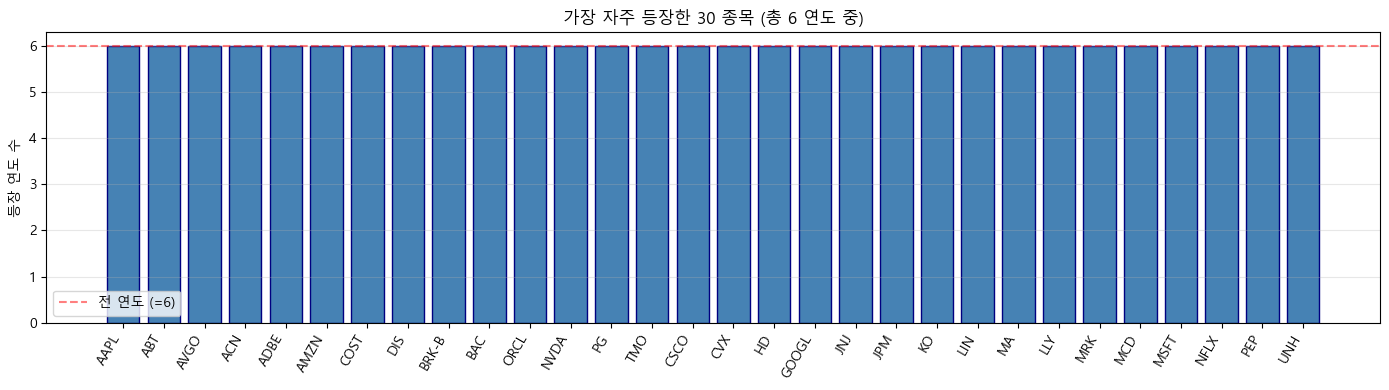


매 연도 등장 종목 수 (안정 대형주): 33
2회 이하 등장 종목 수 (변동 영역): 23


In [5]:
# 4-3. 종목 빈도 — 매년 등장 횟수 (대형주 안정성 시각화)
ticker_freq = history.groupby('ticker').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
top30 = ticker_freq.head(30)
ax.bar(range(len(top30)), top30.values, color='steelblue', edgecolor='navy')
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(top30.index, rotation=60, ha='right')
ax.set_ylabel('등장 연도 수')
ax.set_title(f'가장 자주 등장한 30 종목 (총 {len(OOS_YEARS)} 연도 중)')
ax.axhline(len(OOS_YEARS), ls='--', color='red', alpha=0.5, label=f'전 연도 (={len(OOS_YEARS)})')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'top_ticker_frequency.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n매 연도 등장 종목 수 (안정 대형주): {(ticker_freq == len(OOS_YEARS)).sum()}')
print(f'2회 이하 등장 종목 수 (변동 영역): {(ticker_freq <= 2).sum()}')

## §5. CSV 저장 + 요약 출력

In [6]:
out_csv = DATA_DIR / 'universe_top50_history.csv'
history.to_csv(out_csv, index=False)
print(f'저장 완료: {out_csv}')
print(f'\n행 수: {len(history)}, 컬럼: {list(history.columns)}\n')

# 연도별 첫 5 종목 미리보기
print('=' * 80)
print('연도별 시총 상위 5 종목')
print('=' * 80)
for year in OOS_YEARS:
    top5 = history.loc[(history['oos_year'] == year) & (history['mcap_rank'] <= 5)]
    print(f'\n{year} (cutoff={top5["cutoff_date"].iloc[0].date()}):')
    for _, row in top5.iterrows():
        new_tag = ' (신규)' if row['is_new'] else ''
        print(f'  {row["mcap_rank"]:2d}. {row["ticker"]:8s} ${row["mcap_value"]/1e9:.1f}B{new_tag}')

저장 완료: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\data\universe_top50_history.csv

행 수: 300, 컬럼: ['oos_year', 'ticker', 'mcap_rank', 'mcap_value', 'cutoff_date', 'is_new']

연도별 시총 상위 5 종목

2020 (cutoff=2019-12-31):
   1. AAPL     $1258.1B (신규)
   2. MSFT     $1139.7B (신규)
   3. AMZN     $916.2B (신규)
   4. GOOGL    $915.0B (신규)
   5. BRK-B    $553.9B (신규)

2021 (cutoff=2020-12-31):
   1. AAPL     $2194.0B
   2. AMZN     $1634.2B
   3. MSFT     $1609.9B
   4. GOOGL    $1176.9B
   5. TSLA     $668.9B (신규)

2022 (cutoff=2021-12-31):
   1. AAPL     $2850.8B
   2. MSFT     $2486.6B
   3. GOOGL    $1906.0B
   4. AMZN     $1691.0B
   5. TSLA     $1061.3B

2023 (cutoff=2022-12-31):
   1. AAPL     $2034.3B
   2. MSFT     $1742.0B
   3. GOOGL    $1135.6B
   4. AMZN     $856.9B
   5. BRK-B    $681.8B

2024 (cutoff=2023-12-31):
   1. AAPL     $2963.6B
   2. MSFT     $2747.5B
   3. GOOGL    $1740.0B
   4. AMZN     $1570.1B
   5. NVDA     $1222.4B

2025 (cutoff=2024-12-31):

## 다음 단계

→ **Step 2**: `02_data_collection.ipynb` — universe 50 종목의 일별 OHLCV + 시장 데이터 수집.

`data/universe_top50_history.csv` 의 unique 종목 list 가 입력이 됨.